# 02 — Nowcast case study: the 22 Sep 2026 flash floods

**Stage 5 qualitative case study.** On 22 Sep 2026 a convective storm over the Bukit Timah / Dunearn corridor
produced PUB flash-flood reports on **King's Road (17:11 SGT)** and **Coronation Road (17:15 SGT)**, after a run of
flood-risk warnings from 16:41 SGT. This date lies inside the pinned **test** split (14–25 Sep 2026), so none of these
frames were used for training.

The Definition of Done asks for "at least one heavy-rain event (≥30 mm/hr for ≥30 min)". It originally said "from 2023";
the radar archive only begins on 22 May 2026, so the case was moved to this event (decision recorded 2026-09-26).

**How to read the leads.** The model sees 6 frames (t−6 … t−1, 5-min spacing). A nominal "30-min" model predicts frame
t+6, which is **35 min after the last observed frame**; "60" and "90" likewise mean 65 and 95 min. Each lead has its own
model (checkpoint stamped with its `target_offset`).

**Inputs** (no GPU, no full dataset needed):
- observed radar: `data/processed/radar.zarr` (only the frames for this afternoon are read);
- forecasts: `data/processed/eval_cache/case_22sep_lead{30,60,90}.npz`, from `scripts/case_study_forecasts.py`
  (8 ensemble members per forecast, one forecast per 10 min, targets 15:30–18:30 SGT). Leads whose cache is missing are
  skipped.

All times below are **SGT (UTC+8)**.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SGT = np.timedelta64(8, "h")
def sgt(t):
    return pd.Timestamp(np.datetime64(t, "ns") + SGT).strftime("%H:%M")

rain = (xr.open_zarr(ROOT / "data/processed/radar.zarr", consolidated=True).rain_rate
          .sel(time=slice("2026-09-22T05:00", "2026-09-22T11:00")).load())
lat, lon = rain.lat.values, rain.lon.values
EXTENT = [lon.min(), lon.max(), lat.min(), lat.max()]   # lat is descending -> origin='upper'
PX_KM = 0.290

ev = pd.read_parquet(ROOT / "data/processed/flood_eval_dataset.parquet")
ev = ev[ev.event_datetime.astype(str).str.startswith("2026-09-22")]
sites = ev[ev.geocoded & ev.message_type.isin(["FLASH_FLOOD", "FLOOD_RISK"])].copy()
sites["name"] = sites.location_str.str.replace(r"\s*\[.*\]", "", regex=True).str.strip()
sites["sgt"] = [sgt(t) for t in sites.event_datetime.values]
print(f"{len(rain.time)} radar frames 13:00-19:00 SGT; domain {len(lat)}x{len(lon)} px at {PX_KM} km")
sites[["sgt", "message_type", "name", "location_lat_idx", "location_lon_idx"]]

73 radar frames 13:00-19:00 SGT; domain 120x217 px at 0.29 km


,sgt,message_type,name,location_lat_idx,location_lon_idx
89,16:46,FLOOD_RISK,Watten Drive,49,93
90,16:47,FLOOD_RISK,King's Road (from Prince Road to Lutheran Road),52,93
91,16:52,FLOOD_RISK,Hillcrest Rd (Watten Rise to Dunearn Rd),48,93
92,16:54,FLOOD_RISK,Cluny Pk Rd (from Jln Kembang Melati to Bt Tim...,53,95
95,17:03,FLOOD_RISK,Coronation Road,52,92
97,17:08,FLOOD_RISK,Punggol Way (slip road to TPE),16,131
98,17:11,FLASH_FLOOD,King's Road (from Prince Road to Lutheran Road),52,93
99,17:15,FLASH_FLOOD,Coronation Road (from Prince Road to Bukit Tim...,52,92


In [2]:
# Forecast caches, one per lead (each written by its own model)
fc = {}
for lead in (30, 60, 90):
    p = ROOT / f"data/processed/eval_cache/case_22sep_lead{lead}.npz"
    if p.exists():
        z = np.load(p)
        fc[lead] = dict(ens=z["ens"].astype("float32"), times=z["target_times"].astype("datetime64[ns]"),
                        off=int(z["lead_steps"]))
        print(f"lead {lead}: {len(fc[lead]['times'])} forecasts x {fc[lead]['ens'].shape[1]} members, "
              f"{(fc[lead]['off'] + 1) * 5} min after the last observed frame")
    else:
        print(f"lead {lead}: no cache yet (run scripts/case_study_forecasts.py with that lead's checkpoint)")

# Colour scale shared by every map
LEVELS = [0.5, 1, 2, 5, 10, 20, 30, 50, 100]
CMAP = ListedColormap(["#c6e8ff", "#7cc3f5", "#2f8fd8", "#3fbf4f", "#f2e03c", "#f59a23", "#e8321e", "#9b1bb5"])
CMAP.set_under("white")
NORM = BoundaryNorm(LEVELS, CMAP.N)

def show(ax, field, title, **kw):
    im = ax.imshow(field, extent=EXTENT, origin="upper", **({"cmap": CMAP, "norm": NORM} | kw))
    ax.scatter(sites.location_lon, sites.location_lat, s=18, facecolor="none", edgecolor="k", lw=1)
    ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([])
    return im

lead 30: 19 forecasts x 8 members, 35 min after the last observed frame
lead 60: 19 forecasts x 8 members, 65 min after the last observed frame
lead 90: 19 forecasts x 8 members, 95 min after the last observed frame


## 1. Does the event meet the heavy-rain criterion?

Observed rain rate near the flood sites: the maximum over a 7×7-pixel box (≈2×2 km) centred on King's Road. A single
pixel is too noisy to judge "sustained" rain. The box contains both flash-flood sites (King's Road, Coronation Road)
and the Watten Drive and Cluny Park warnings; Hillcrest Road sits one pixel north of it.

Longest spell >= 30 mm/hr: 100 min, 15:55-17:35 SGT; peak 85 mm/hr
Criterion (>= 30 mm/hr for >= 30 min): MET


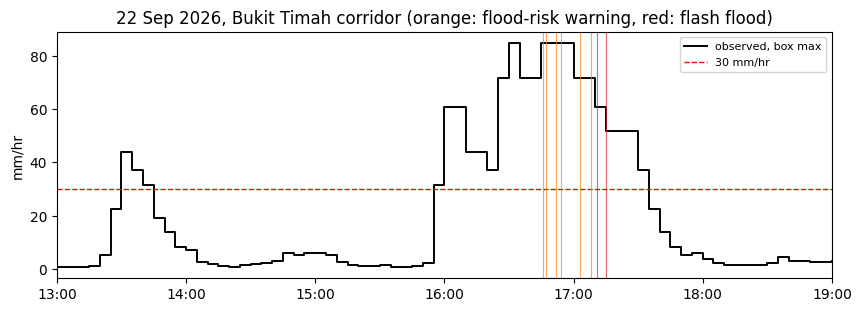

In [3]:
R = 3                                   # box half-width in pixels (~0.9 km)
ci, cj = 52, 93                         # King's Road grid cell (from the geocoder)
box = rain.isel(lat=slice(ci - R, ci + R + 1), lon=slice(cj - R, cj + R + 1)).max(("lat", "lon"))
t_sgt = rain.time.values + SGT

heavy = box.values >= 30
# longest run of consecutive 5-min frames at or above 30 mm/hr
runs, cur, best, best_end = [], 0, 0, None
for k, h in enumerate(heavy):
    cur = cur + 1 if h else 0
    if cur > best:
        best, best_end = cur, k
start = best_end - best + 1
print(f"Longest spell >= 30 mm/hr: {best * 5} min, {sgt(rain.time.values[start])}-"
      f"{sgt(rain.time.values[best_end] + np.timedelta64(5, 'm'))} SGT; peak {float(box.max()):.0f} mm/hr")
print("Criterion (>= 30 mm/hr for >= 30 min):", "MET" if best * 5 >= 30 else "NOT met")

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.step(t_sgt, box.values, where="post", color="k", lw=1.4, label="observed, box max")
ax.axhline(30, color="r", ls="--", lw=1, label="30 mm/hr")
for _, s in sites.iterrows():
    ax.axvline(np.datetime64(s.event_datetime, "ns") + SGT,
               color="tab:red" if s.message_type == "FLASH_FLOOD" else "tab:orange", lw=0.8, alpha=0.7)
ax.set_ylabel("mm/hr"); ax.set_title("22 Sep 2026, Bukit Timah corridor (orange: flood-risk warning, red: flash flood)")
ax.legend(loc="upper right", fontsize=8); ax.set_xlim(t_sgt[0], t_sgt[-1])
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M")); plt.show()

## 2. What the radar saw

Observed frames every 20 minutes through the storm. Circles are the geocoded PUB warning/flood locations for the day.

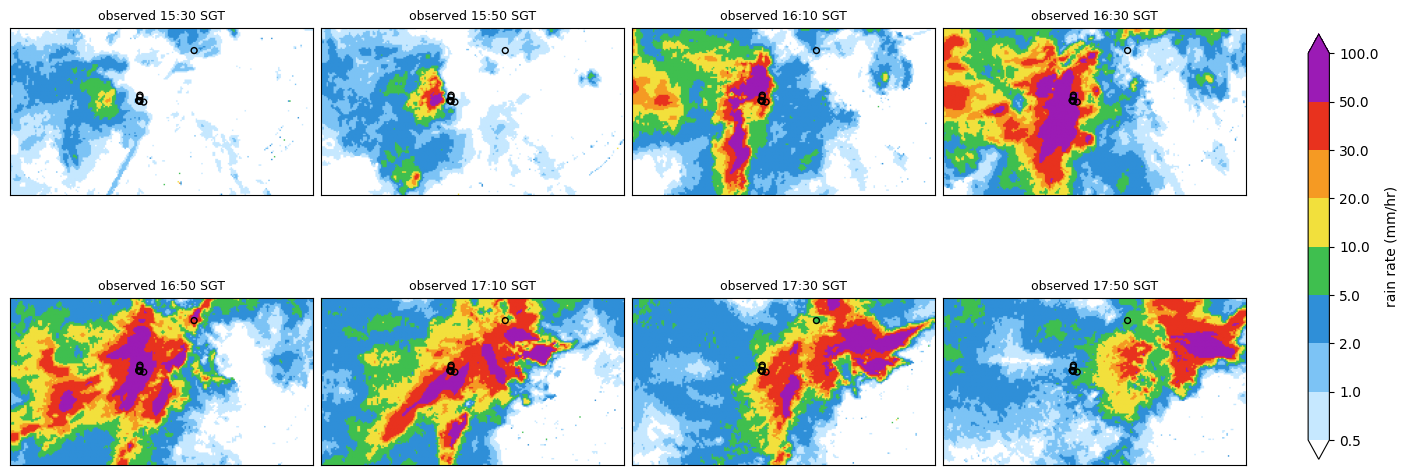

In [4]:
show_t = np.arange(np.datetime64("2026-09-22T07:30"), np.datetime64("2026-09-22T10:00"), np.timedelta64(20, "m"))
fig, axes = plt.subplots(2, 4, figsize=(14, 5.4), layout="constrained")
for ax, t in zip(axes.flat, show_t):
    im = show(ax, rain.sel(time=t).values, f"observed {sgt(t)} SGT")
fig.colorbar(im, ax=axes, shrink=0.8, label="rain rate (mm/hr)", extend="both")
plt.show()

## 3. Forecast maps

For each lead, three targets: **onset** (16:00), **peak** (16:50) and **decay** (17:30 SGT). Columns:
observed at the target time · persistence (the last frame the model saw) · ensemble mean · ensemble probability of
≥10 mm/hr (share of the 8 members).

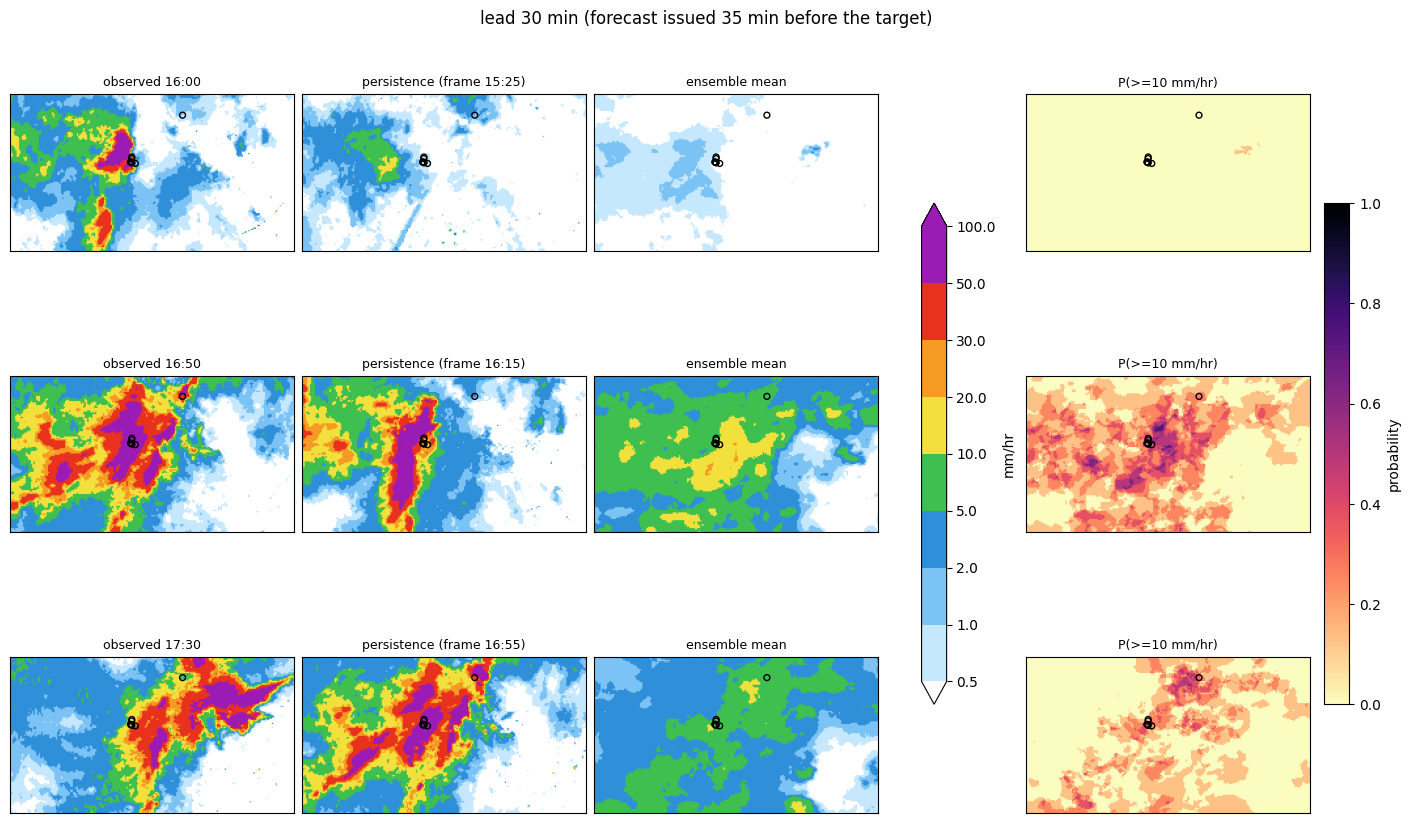

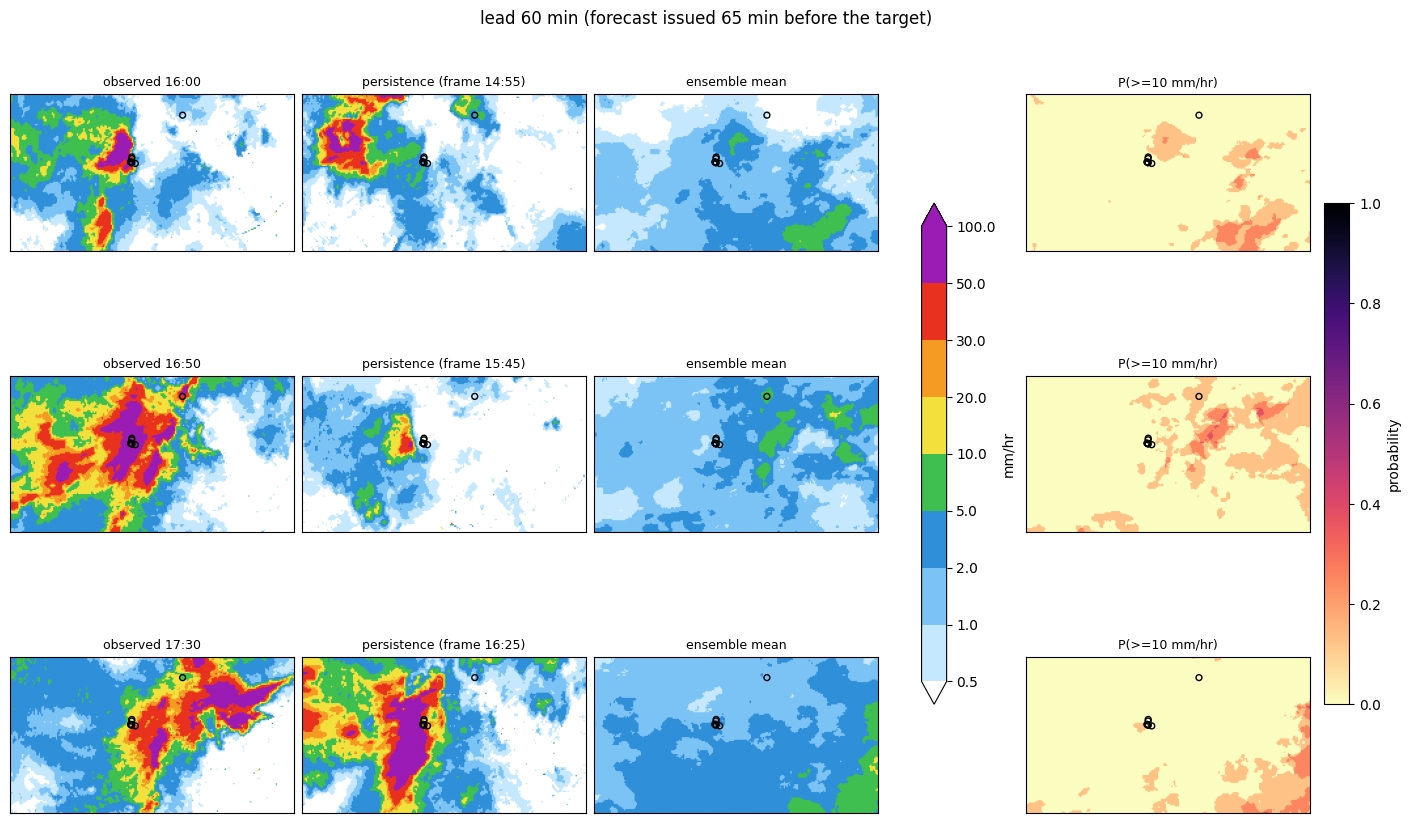

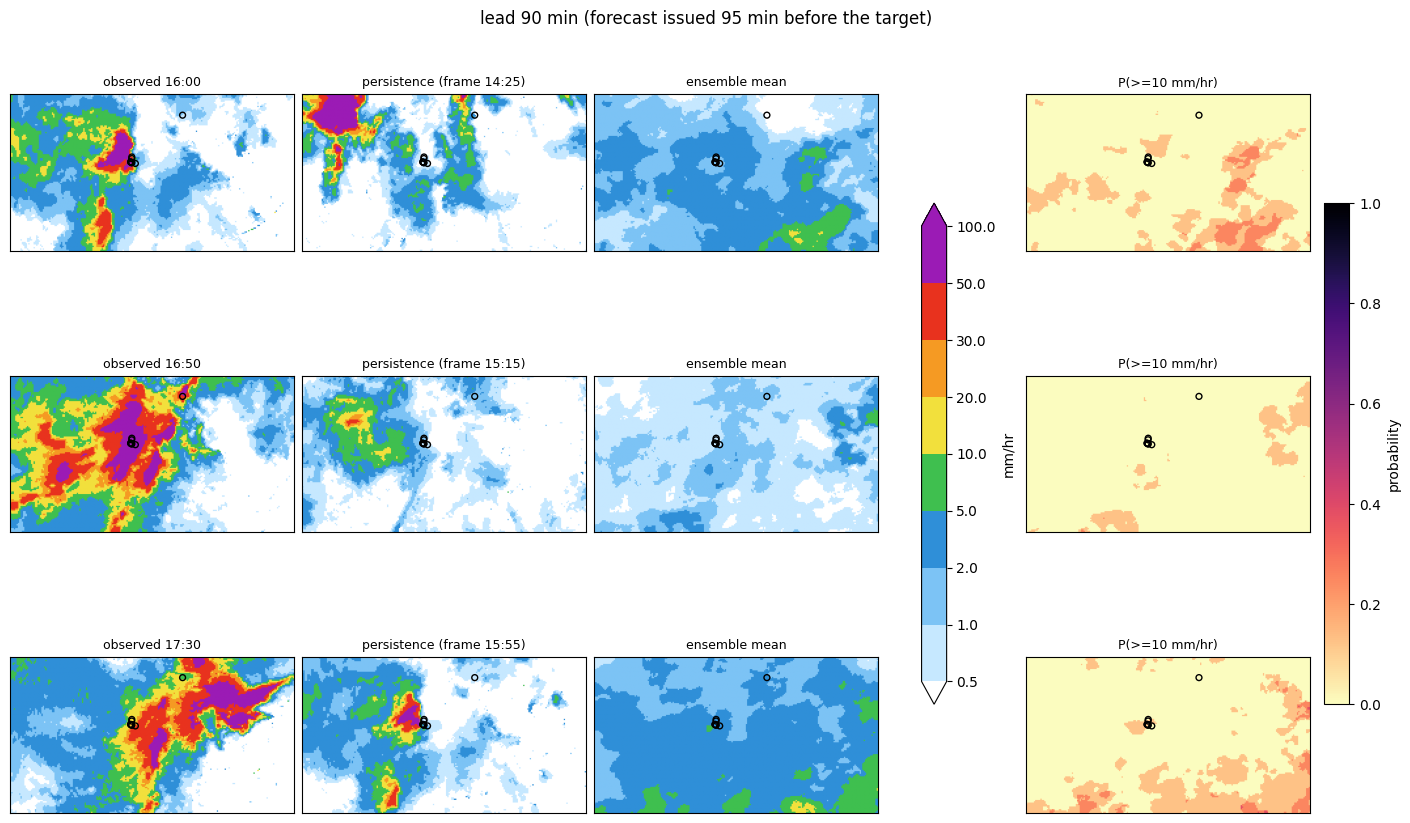

In [5]:
TARGETS = [np.datetime64("2026-09-22T08:00"), np.datetime64("2026-09-22T08:50"), np.datetime64("2026-09-22T09:30")]
P_CMAP = plt.get_cmap("magma_r")

def persistence(t, off):
    return rain.sel(time=np.datetime64(t, "ns") - np.timedelta64((off + 1) * 5, "m")).values

for lead, f in fc.items():
    fig, axes = plt.subplots(len(TARGETS), 4, figsize=(14, 2.9 * len(TARGETS)), layout="constrained")
    for r, t in enumerate(TARGETS):
        k = int(np.where(f["times"] == np.datetime64(t, "ns"))[0][0])
        issue = np.datetime64(t, "ns") - np.timedelta64((f["off"] + 1) * 5, "m")
        im = show(axes[r, 0], rain.sel(time=t).values, f"observed {sgt(t)}")
        show(axes[r, 1], persistence(t, f["off"]), f"persistence (frame {sgt(issue)})")
        show(axes[r, 2], f["ens"][k].mean(0), f"ensemble mean")
        imp = show(axes[r, 3], (f["ens"][k] >= 10).mean(0), "P(>=10 mm/hr)", cmap=P_CMAP, norm=None, vmin=0, vmax=1)
    fig.suptitle(f"lead {lead} min (forecast issued {(f['off'] + 1) * 5} min before the target)")
    fig.colorbar(im, ax=axes[:, :3], shrink=0.6, label="mm/hr", extend="both")
    fig.colorbar(imp, ax=axes[:, 3], shrink=0.6, label="probability")
    plt.show()

## 4. The flood cell through the afternoon, all leads

Same 2×2 km box as section 1. The shaded band spans the ensemble members' box maxima (min–max over the 8 members),
the line is their median. Below it is the probability that the box sees ≥10 mm/hr and ≥30 mm/hr. Everything is
plotted at the **target** time, so the gap between a forecast and the observed curve is what the forecaster would have
missed `lead` minutes earlier.

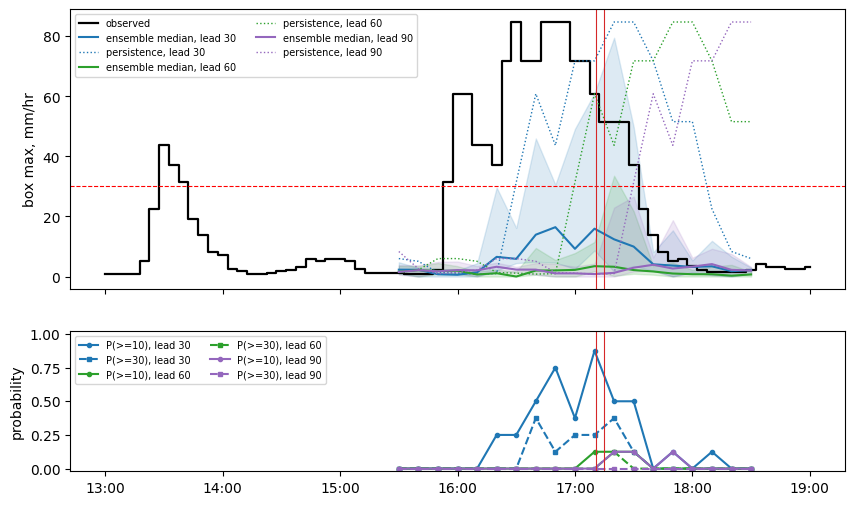

,lead,target,observed,persistence,ens_median,P10,P30
0,30,15:30,1.350000,5.990000,2.290000,0.00,0.00
1,30,15:40,0.700000,5.080000,2.270000,0.00,0.00
2,30,15:50,2.220000,1.350000,0.770000,0.00,0.00
3,30,16:00,60.849998,1.140000,0.600000,0.00,0.00
4,30,16:10,43.700001,0.820000,1.410000,0.00,0.00
5,30,16:20,37.029999,0.970000,6.560000,0.25,0.00
6,30,16:30,84.739998,31.379999,5.900000,0.25,0.00
7,30,16:40,71.809998,60.849998,13.940000,0.50,0.38
8,30,16:50,84.739998,43.700001,16.440001,0.75,0.12
9,30,17:00,71.809998,71.809998,9.240000,0.38,0.25


In [6]:
def box_max(a):                       # (..., H, W) -> (...)
    return a[..., ci - R:ci + R + 1, cj - R:cj + R + 1].max(axis=(-2, -1))

rows = []
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
axes[0].step(t_sgt, box.values, where="mid", color="k", lw=1.6, label="observed")
colors = {30: "tab:blue", 60: "tab:green", 90: "tab:purple"}
for lead, f in fc.items():
    m = box_max(f["ens"])                                  # (N, members)
    tt = f["times"] + SGT
    axes[0].fill_between(tt, m.min(1), m.max(1), color=colors[lead], alpha=0.15)
    axes[0].plot(tt, np.median(m, 1), color=colors[lead], lw=1.5, label=f"ensemble median, lead {lead}")
    pers = np.array([box_max(persistence(t, f["off"])) for t in f["times"]])
    axes[0].plot(tt, pers, color=colors[lead], ls=":", lw=1, label=f"persistence, lead {lead}")
    axes[1].plot(tt, (m >= 10).mean(1), color=colors[lead], marker="o", ms=3, label=f"P(>=10), lead {lead}")
    axes[1].plot(tt, (m >= 30).mean(1), color=colors[lead], marker="s", ms=3, ls="--", label=f"P(>=30), lead {lead}")
    obs = np.array([box_max(rain.sel(time=t).values) for t in f["times"]])
    for t, o, p, mm, p10, p30 in zip(f["times"], obs, pers, np.median(m, 1), (m >= 10).mean(1), (m >= 30).mean(1)):
        rows.append(dict(lead=lead, target=sgt(t), observed=o, persistence=p, ens_median=mm, P10=p10, P30=p30))
axes[0].axhline(30, color="r", ls="--", lw=0.8)
axes[0].set_ylabel("box max, mm/hr"); axes[0].legend(fontsize=7, ncol=2)
axes[1].set_ylabel("probability"); axes[1].set_ylim(-0.02, 1.02); axes[1].legend(fontsize=7, ncol=2)
for s in sites[sites.message_type == "FLASH_FLOOD"].event_datetime.values:
    for a in axes: a.axvline(np.datetime64(s, "ns") + SGT, color="tab:red", lw=0.8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.show()
table = pd.DataFrame(rows).round(2)
table

## 5. Warning lead time

When would each model first have raised a flag for this cell, and how does that compare with the rain onset and the
first flash-flood report? A flag here is "at least 2 of 8 members (P ≥ 0.25) put ≥10 mm/hr in the box". The time that
matters to a user is the **issue** time: target time minus the lead.

In [7]:
# Onset = start of the unbroken >= 10 mm/hr run that contains the >= 30 mm/hr spell
# (earlier showers around 13:30 SGT are a separate, light episode).
k0 = start
while k0 > 0 and box.values[k0 - 1] >= 10:
    k0 -= 1
onset = rain.time.values[k0]
first_flood = sites[sites.message_type == "FLASH_FLOOD"].event_datetime.min()
print(f"observed >= 10 mm/hr in the box from {sgt(onset)} SGT; first flash-flood report {sgt(first_flood)} SGT\n")
for lead, f in fc.items():
    p10 = (box_max(f["ens"]) >= 10).mean(1)
    hit = np.where(p10 >= 0.25)[0]
    if len(hit) == 0:
        print(f"lead {lead}: never reached P >= 0.25"); continue
    t = f["times"][hit[0]]
    issued = t - np.timedelta64((f["off"] + 1) * 5, "m")
    lag = (issued - np.datetime64(onset, "ns")) / np.timedelta64(1, "m")
    ahead = (np.datetime64(first_flood, "ns") - issued) / np.timedelta64(1, "m")
    print(f"lead {lead}: first flag for target {sgt(t)}, issued {sgt(issued)} SGT -> "
          f"{lag:+.0f} min relative to rain onset, {ahead:.0f} min before the first flood report")

observed >= 10 mm/hr in the box from 15:55 SGT; first flash-flood report 17:11 SGT

lead 30: first flag for target 16:20, issued 15:45 SGT -> -10 min relative to rain onset, 86 min before the first flood report
lead 60: never reached P >= 0.25
lead 90: never reached P >= 0.25


## 6. Verdict

**Lead 30 (35 min after the last frame).**

1. **The first minutes of the storm are missed, but not by much.** The cell grew rapidly about 6 km from King's Road
   from ~15:30 SGT (≥10 mm/hr area: 112 px at 15:30 → 1028 px at 15:55) and reached the box at 15:55. Forecasts
   issued at 15:25 and 15:35 (targets 16:00, 16:10) had near-zero rain in the box while 44–61 mm/hr fell; so did
   persistence. From the 15:45 issue onward the ensemble flags the box, 10 min before the rain arrived.
2. **During the storm the ensemble carries a real but under-intense signal.** 25–88% of members put ≥10 mm/hr in the
   box, and up to 3 of 8 put ≥30 mm/hr. The ensemble median is roughly 5× too weak (≈10–16 vs 50–85 mm/hr observed),
   matching the aggregate intensity bias (≈0.5 at ≥10 mm/hr).
3. **The decay is better than persistence.** After 17:30 SGT persistence still shows 50–85 mm/hr while the observed rain
   drops below 15; the ensemble correctly falls to low probabilities.
4. **As a flood warning:** the first P ≥ 0.25 flag (issued 15:45 SGT) came 56 min before PUB's first flood-risk warning
   (16:41) and 86 min before the King's Road flash-flood report (17:11). It is a weak flag (2 of 8 members).

**Leads 60 and 90 (65 and 95 min).** These are the warm-started models (initialised from the 30-min model). Neither
ever reaches P ≥ 0.25 in the box: the highest is 0.12, including forecasts issued while the storm was already overhead.
This matches the test-period scores. At light rain (2 mm/hr) they now tie persistence at 60 min and edge it at 90 min
(FSS 0.56 vs 0.56 and 0.57 vs 0.51). At heavy rain they stay well below it (0.06 vs 0.24 and 0.09 vs 0.16). Use them
for "will it rain around here", not for flash-flood warning. Heavy-rain skill from radar alone does not reach past 30 min.

This is one event; it illustrates the aggregate scores and is not evidence on its own.